# Практическая работа № 2
## Разведочный анализ данных о подержанных автомобилях

Уровень: C  
ФИО: Кашымбеков Актан Ийгиликович

### Цель работы
Изучить распределения и качество данных, проверить три статистические
гипотезы, выявить потенциальные утечки и предложить признаки
для прогнозирования запрашиваемой цены автомобиля.

### Данные
Used Car Price Prediction Dataset, автор Taeef Najib.
Источник:
https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset

Одна строка — объявление о продаже автомобиля.
Целевая переменная — price, запрашиваемая цена в долларах США.

Цена объявления может отличаться от фактической цены продажи.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [23]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [24]:
from scipy import stats

plt.rcParams['figure.figsize'] = (9, 5) # Runtime Configuration Parameters
plt.rcParams['axes.grid'] = True

In [25]:
data_path = Path('../data/raw/used_cars.csv')

if not data_path.exists():
    data_path = Path('/data/raw/used_cars.csv')
    
df_raw = pd.read_csv(data_path)

df = df_raw.copy()

print(df.shape)
df.info()
df.head()

(4009, 12)
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [26]:
price_text = (
    df['price']
    .astype('string')
    .str.replace('$','', regex=False)
    .str.replace(',','', regex=False)
    .str.strip()
)

mileage_text = (
    df['milage']
    .astype('string')
    .str.replace('mi','', regex=False)
    .str.replace('.','', regex=False)
    .str.replace(',','',regex=False)
    )

df['price_usd'] = pd.to_numeric(price_text, errors='coerce')
df['mileage_miles'] = pd.to_numeric(mileage_text, errors='coerce')
df['model_year'] = pd.to_numeric(df['model_year'], errors='coerce')

display(
    df[["price", "price_usd", "milage", "mileage_miles"]].head()
)

print(f'unable to convert price: \n{(df['price'].notna() & df['price_usd'].isna().sum())}')

print(f'unable to convert mileage: \n {(df['milage'].notna() & df['mileage_miles'].isna().sum())}')


,price,price_usd,milage,mileage_miles
0,"$10,300",10300,"51,000 mi.",51000
1,"$38,005",38005,"34,742 mi.",34742
2,"$54,598",54598,"22,372 mi.",22372
3,"$15,500",15500,"88,900 mi.",88900
4,"$34,999",34999,"9,835 mi.",9835


unable to convert price: 
0       False
1       False
2       False
3       False
4       False
        ...  
4004    False
4005    False
4006    False
4007    False
4008    False
Name: price, Length: 4009, dtype: bool
unable to convert mileage: 
 0       False
1       False
2       False
3       False
4       False
        ...  
4004    False
4005    False
4006    False
4007    False
4008    False
Name: milage, Length: 4009, dtype: bool


## 1. Проверка качества данных

Проверяю пропуски, полные дубликаты, категории и подозрительные
числовые значения. Не удаляю необычные объявления автоматически:
высокая цена или большой пробег сами по себе не доказывают ошибку.

In [27]:
missing = pd.DataFrame({
    "Количество пропусков": df_raw.isna().sum(),
    "Доля пропусков, %": df_raw.isna().mean().mul(100).round(2)
})

display(missing.sort_values("Количество пропусков", ascending=False))

print("Полных дубликатов:", df_raw.duplicated().sum())

for column in ["fuel_type", "accident", "clean_title"]:
    print(f"\nСтолбец: {column}")
    display(df_raw[column].value_counts(dropna=False))

,Количество пропусков,"Доля пропусков, %"
clean_title,596,14.87
fuel_type,170,4.24
accident,113,2.82
brand,0,0.00
milage,0,0.00
model_year,0,0.00
model,0,0.00
engine,0,0.00
ext_col,0,0.00
transmission,0,0.00


Полных дубликатов: 0

Столбец: fuel_type


fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64


Столбец: accident


accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64


Столбец: clean_title


clean_title
Yes    3413
NaN     596
Name: count, dtype: int64

In [28]:
display(
    df[["price_usd", "mileage_miles", "model_year"]]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
    .round(2)
)

print("Цена <= 0:", df["price_usd"].le(0).sum())
print("Пробег < 0:", df["mileage_miles"].lt(0).sum())

display(
    df.nlargest(10, "price_usd")[
        ["brand", "model", "model_year", "mileage_miles", "price_usd"]
    ]
)

,price_usd,mileage_miles,model_year
count,4009.0,4009.0,4009.00
mean,44553.19,64717.55,2015.52
std,78710.64,52296.6,6.10
min,2000.0,100.0,1974.00
1%,4000.0,634.68,1997.08
25%,17200.0,23044.0,2012.00
50%,31000.0,52775.0,2017.00
75%,49990.0,94100.0,2020.00
99%,272713.28,222428.0,2023.00
max,2954083.0,405000.0,2024.00


Цена <= 0: 0
Пробег < 0: 0


,brand,model,model_year,mileage_miles,price_usd
693,Maserati,Quattroporte Base,2005,32000,2954083
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330,1950995
3046,Porsche,Carrera GT Base,2005,4400,1599000
1356,Lamborghini,Aventador SVJ Base,2021,6987,749950
624,Rolls-Royce,Cullinan,2022,398,695000
979,Lamborghini,Aventador SVJ Base,2019,6929,649999
1615,Rolls-Royce,Phantom,2023,1560,599995
1508,Rolls-Royce,Phantom,2018,7585,599000
3655,Lamborghini,Aventador S Base,2018,5858,491836
1061,Dodge,Viper GTC,2017,1389,489995


### Обнаруженные проблемы данных

1. Цена и пробег хранятся строками с обозначениями единиц.
   Для анализа созданы числовые столбцы.
2. Есть пропуски в fuel_type, accident и clean_title.
3. В fuel_type встречаются непонятные значения � и not supported.
4. Пропуск accident нельзя считать отсутствием аварий.
5. Пропуск clean_title нельзя автоматически считать значением «Нет».
6. engine и transmission содержат текстовые описания, которые
   потребуют отдельной обработки при подготовке признаков.
7. Полных дубликатов не обнаружено, но это не исключает повторные
   объявления одного автомобиля с изменёнными полями.

## 2. Распределение цены

Гистограмма показывает, в каких диапазонах находится больше объявлений.

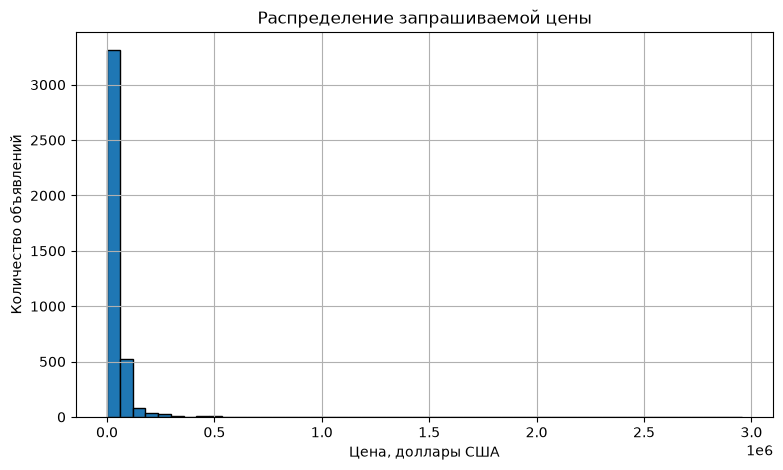

Средняя цена: 44553.19
Медианная цена: 31000.0


In [29]:
prices = df["price_usd"].dropna()

fig, ax = plt.subplots()
ax.hist(prices, bins=50, edgecolor="black")
ax.set_title("Распределение запрашиваемой цены")
ax.set_xlabel("Цена, доллары США")
ax.set_ylabel("Количество объявлений")
plt.show()

print("Средняя цена:", round(prices.mean(), 2))
print("Медианная цена:", round(prices.median(), 2))

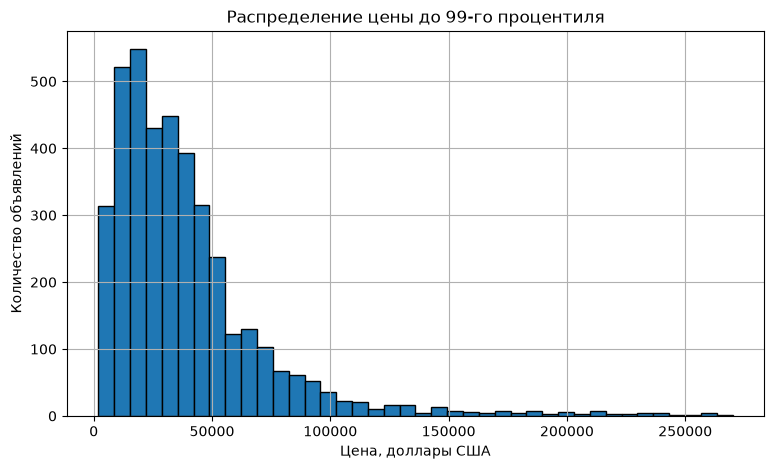

За пределами этого графика: 41


In [30]:
upper_price = prices.quantile(0.99)

fig, ax = plt.subplots()
ax.hist(prices[prices <= upper_price], bins=40, edgecolor="black")
ax.set_title("Распределение цены до 99-го процентиля")
ax.set_xlabel("Цена, доллары США")
ax.set_ylabel("Количество объявлений")
plt.show()

print("За пределами этого графика:", (prices > upper_price).sum())

### Выводы

Полное распределение: [опиши форму и наличие длинного хвоста].
Средняя цена — [...], медианная — [...].

График до 99-го процентиля: основная часть показанных объявлений
сосредоточена в диапазоне [...]. Ограничение применено только
для удобства визуализации.

## 3. Статистические гипотезы

### Гипотеза 1: модельный год и цена
H0: ранговая корреляция Спирмена между модельным годом и ценой равна нулю.
H1: ранговая корреляция отличается от нуля.

### Гипотеза 2: пробег и цена
H0: ранговая корреляция Спирмена между пробегом и ценой равна нулю.
H1: ранговая корреляция отличается от нуля.

Для первых двух гипотез использую корреляцию Спирмена:
она оценивает монотонную связь и не требует нормального
распределения исходных признаков.

### Гипотеза 3: сообщения об авариях и цена
H0: распределения цен одинаковы в двух группах accident.
H1: распределения различаются.

Использую двусторонний тест Манна — Уитни для двух независимых групп.
Без дополнительных предположений о форме распределений
не трактую его как проверку исключительно равенства медиан.

Уровень значимости для семейства трёх проверок — 0,05.
Использую поправку Бонферрони: порог для каждого теста — 0,05 / 3.

Результаты описывают связи в объявлениях и не доказывают причинность.

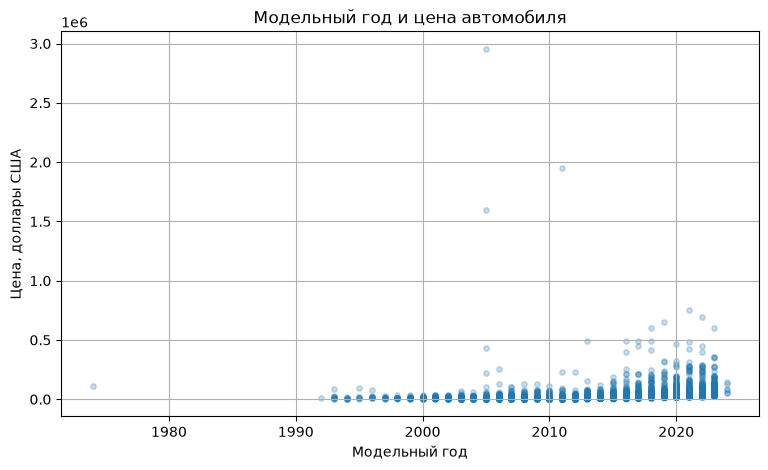

Количество наблюдений: 4009
Корреляция Спирмена: 0.697
p-value: 0


In [31]:
year_data = df[["model_year", "price_usd"]].dropna()

fig, ax = plt.subplots()
ax.scatter(
    year_data["model_year"],
    year_data["price_usd"],
    alpha=0.25,
    s=15
)
ax.set_title("Модельный год и цена автомобиля")
ax.set_xlabel("Модельный год")
ax.set_ylabel("Цена, доллары США")
plt.show()

rho_year, p_year = stats.spearmanr(
    year_data["model_year"],
    year_data["price_usd"]
)

print("Количество наблюдений:", len(year_data))
print(f"Корреляция Спирмена: {rho_year:.3f}")
print(f"p-value: {p_year:.3g}")

### Вывод по модельному году

На графике наблюдается [...].

Корреляция Спирмена составила [...], направление связи — [...].
p-value = [...]; сравнение с порогом 0,05 / 3 даёт основание
[отклонить / не отклонять] H0.

Модельный год [выглядит / не выглядит] перспективным признаком
на основании полученного результата. Его полезность для модели
нужно будет проверить отдельно.

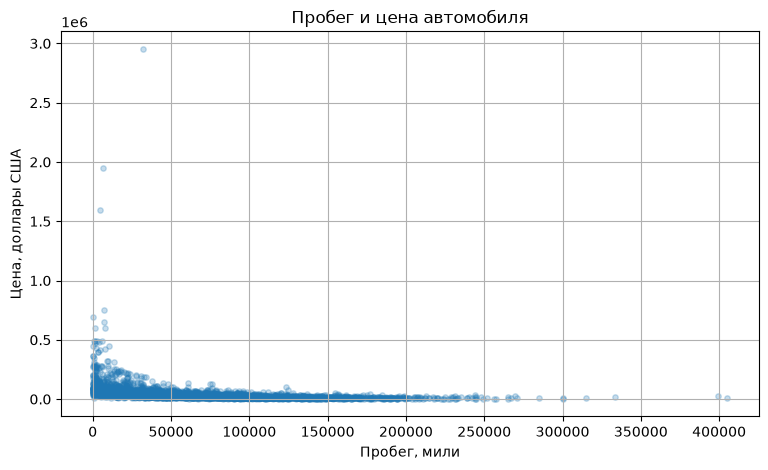

Количество наблюдений: 4009
Корреляция Спирмена: -0.755
p-value: 0


In [32]:
mileage_data = df[["mileage_miles", "price_usd"]].dropna()

fig, ax = plt.subplots()
ax.scatter(
    mileage_data["mileage_miles"],
    mileage_data["price_usd"],
    alpha=0.25,
    s=15
)
ax.set_title("Пробег и цена автомобиля")
ax.set_xlabel("Пробег, мили")
ax.set_ylabel("Цена, доллары США")
plt.show()

rho_mileage, p_mileage = stats.spearmanr(
    mileage_data["mileage_miles"],
    mileage_data["price_usd"]
)

print("Количество наблюдений:", len(mileage_data))
print(f"Корреляция Спирмена: {rho_mileage:.3f}")
print(f"p-value: {p_mileage:.3g}")

### Вывод по пробегу

На графике наблюдается [...].

Корреляция Спирмена составила [...], направление связи — [...].
p-value = [...]; при выбранном пороге H0 [...].

Связь не означает, что различия цен объясняются только пробегом:
автомобили также различаются по году, марке и другим характеристикам.

In [33]:
no_accident = df.loc[
    df["accident"].eq("None reported"),
    "price_usd"
].dropna()

with_accident = df.loc[
    df["accident"].eq("At least 1 accident or damage reported"),
    "price_usd"
].dropna()

group_summary = pd.DataFrame({
    "Группа": ["Нет сообщения об аварии", "Есть сообщение об аварии"],
    "Количество": [len(no_accident), len(with_accident)],
    "Медианная цена": [no_accident.median(), with_accident.median()],
    "Средняя цена": [no_accident.mean(), with_accident.mean()]
})

display(group_summary.round(2))

,Группа,Количество,Медианная цена,Средняя цена
0,Нет сообщения об аварии,2910,35667.5,49638.07
1,Есть сообщение об аварии,986,20900.0,28831.50


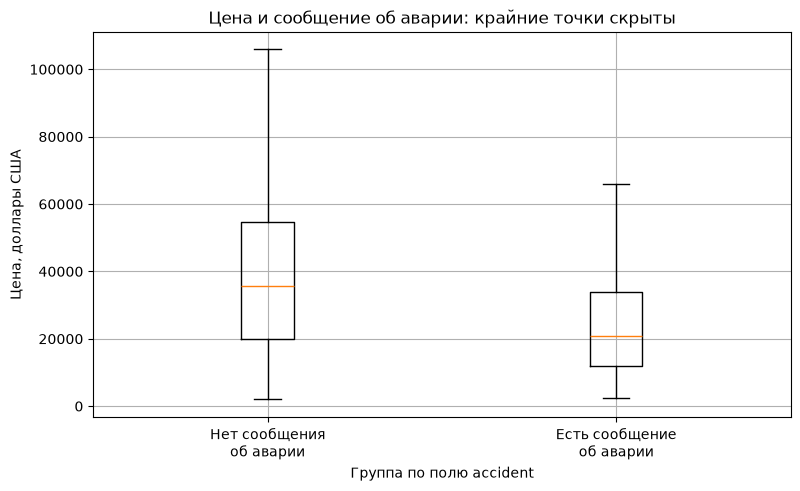

In [34]:
fig, ax = plt.subplots()

ax.boxplot(
    [no_accident, with_accident],
    showfliers=False
)

ax.set_xticks([1, 2])
ax.set_xticklabels([
    "Нет сообщения\nоб аварии",
    "Есть сообщение\nоб аварии"
])

ax.set_title("Цена и сообщение об аварии: крайние точки скрыты")
ax.set_xlabel("Группа по полю accident")
ax.set_ylabel("Цена, доллары США")
plt.show()

In [35]:
u_stat, p_accident = stats.mannwhitneyu(
    with_accident,
    no_accident,
    alternative="two-sided",
    method="asymptotic"
)

rank_effect = (
    2 * u_stat / (len(with_accident) * len(no_accident)) - 1
)

median_difference = (
    with_accident.median() - no_accident.median()
)

print(f"p-value: {p_accident:.3g}")
print(f"Ранговый размер эффекта: {rank_effect:.3f}")
print(f"Разница медиан: {median_difference:.2f} долларов")

p-value: 8.31e-68
Ранговый размер эффекта: -0.370
Разница медиан: -14767.50 долларов


### Вывод по сообщениям об авариях

На boxplot видно [...].

Медианная цена в группе без сообщения об аварии — [...] долларов,
с сообщением — [...] долларов.

p-value теста Манна — Уитни = [...], ранговый размер эффекта = [...].
При выбранном пороге H0 [...].

Сравнение не учитывает различия по марке, году и пробегу.
Поэтому результат нельзя трактовать как причинное влияние аварии
на цену. «None reported» означает отсутствие сообщения,
а не гарантированное отсутствие аварий.

In [36]:
alpha = 0.05
threshold = alpha / 3

results = pd.DataFrame({
    "Гипотеза": [
        "Модельный год и цена",
        "Пробег и цена",
        "Сообщение об аварии и цена"
    ],
    "Тест": [
        "Спирмен",
        "Спирмен",
        "Манна — Уитни"
    ],
    "Размер связи / эффекта": [
        rho_year,
        rho_mileage,
        rank_effect
    ],
    "p-value": [
        p_year,
        p_mileage,
        p_accident
    ]
})

results["Отклоняем H0"] = results["p-value"] < threshold

print(f"Порог с поправкой Бонферрони: {threshold:.5f}")
display(results)

Порог с поправкой Бонферрони: 0.01667


,Гипотеза,Тест,Размер связи / эффекта,p-value,Отклоняем H0
0,Модельный год и цена,Спирмен,0.697388,0.000000e+00,True
1,Пробег и цена,Спирмен,-0.755174,0.000000e+00,True
2,Сообщение об аварии и цена,Манна — Уитни,-0.370218,8.306374e-68,True


## 4. Потенциальные утечки данных

Предполагаю, что модель оценивает запрашиваемую цену по известным
характеристикам автомобиля в момент подготовки объявления.

1. В признаки нельзя включать исходный price, числовую копию price_usd
   или другие преобразования целевой цены.

2. Среднюю цену марки или модели нельзя рассчитывать по всей таблице
   перед разделением данных: в признаки попадут ответы из тестовой части.

3. Заполнение пропусков по медиане, масштабирование и другие
   обучаемые преобразования нужно настраивать только на train.

4. Повторные объявления одного автомобиля могут попасть одновременно
   в train и test и завысить оценку качества. Отсутствие полных
   дубликатов не исключает такую ситуацию.

5. Данные, появившиеся только после момента прогнозирования,
   нельзя использовать как входные признаки.

Поля accident и clean_title не являются утечкой автоматически:
важно, известны ли они в момент прогнозирования.

### Ограничения анализа

Данные объявлений не являются случайной выборкой всех автомобилей.
Возможны повторные объявления и зависимые наблюдения, что ограничивает
интерпретацию статистических тестов.

Проверены отдельные связи без одновременного учёта всех характеристик.
Неотклонение H0 не доказывает отсутствие связи, а статистическая
значимость не равна практической важности.

Для группового сравнения использованы только объявления с известным
значением accident; результат может не распространяться на строки
с пропусками.

## 5. Кандидаты на полезные признаки

| Признак | Основание | Ограничение |
|---|---|---|
| model_year | Спирмен = [...], график показывает [...] | Связь может различаться между марками |
| mileage_miles | Спирмен = [...], график показывает [...] | Пробег связан с возрастом машины |
| accident | Ранговый эффект = [...], сравнение показывает [...] | Есть пропуски, группы отличаются и по другим признакам |

brand, model, engine, transmission и fuel_type также представляют
интерес по смыслу задачи, но их полезность в этой работе отдельно
не проверена.

Окончательную полезность признаков нужно оценивать по качеству модели
на отложенных данных.

## 6. Итог

Выполнен разведочный анализ данных о подержанных автомобилях.
Проверены пропуски, дубликаты и форматы значений.
Построены гистограммы, диаграммы рассеяния и boxplot.
Проверены три статистические гипотезы с поправкой Бонферрони.

Основные результаты:
1. Распределение цены: [...].
2. Связь модельного года с ценой: [...].
3. Связь пробега с ценой: [...].
4. Различия между группами accident: [...].

Для последующей предобработки необходимо определить правила
обработки пропусков и непонятных категорий, а также подготовить
текстовые и категориальные признаки.